In [1]:
import pytensor

pytensor.config.floatX = "float32"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

from pymc_extras.inference.advi.autoguide import AutoDiagonalNormal
from pymc_extras.inference.advi.training import SVIModule, SVITrainer
from typing import Any
import arviz as az

In [3]:
with pm.Model() as m:
    X = pm.Normal("X", 0, 1, size=(100, 3))
    alpha = pm.Normal("alpha", 0, 10)
    beta = pm.Normal("beta", 0, 5, size=(3,))

    mu = alpha + X @ beta
    sigma = pm.HalfNormal("sigma", 1)
    y = pm.Normal("y", mu=mu, sigma=sigma)

    prior = pm.sample_prior_predictive(random_seed=38)

Sampling: [X, alpha, beta, sigma, y]


In [4]:
draw = 123
true_params = {}
true_params["alpha"] = prior.prior.alpha.sel(chain=0, draw=draw).values
true_params["beta"] = prior.prior.beta.sel(chain=0, draw=draw).values
true_params["sigma"] = prior.prior.sigma.sel(chain=0, draw=draw).values

X_data = prior.prior.X.sel(chain=0, draw=draw).values
y_data = prior.prior.y.sel(chain=0, draw=draw).values

In [5]:
true_params

{'alpha': array(11.82213, dtype=float32),
 'beta': array([-0.9251873 ,  0.27270752, -0.20081106], dtype=float32),
 'sigma': array(0.40007043, dtype=float32)}

In [6]:
m_obs = pm.observe(pm.do(m, {X: X_data}), {"y": y_data})

In [7]:
with m_obs:
    idata = pm.sample()

NUTS[nutpie]: [sigma, beta, alpha]


Output()

In [8]:
class SGDOptimizer:
    def __init__(self, learning_rate: float = 1e-5):
        self.learning_rate = learning_rate

    def init(self, params: dict[str, np.ndarray]) -> None:
        return None

    def update(
        self,
        grads: dict[str, np.ndarray],
        state: None,
        params: dict[str, np.ndarray],
    ) -> tuple[dict[str, np.ndarray], None]:
        updated_params = {k: v - self.learning_rate * grads[k] for k, v in params.items()}
        return updated_params, state


class NormalModel(SVIModule):
    def configure_guide(self, model):
        return AutoDiagonalNormal(model)

    def configure_optimizer(self, params: dict[str, np.ndarray]) -> tuple[Any, dict[str, Any]]:
        optimizer = SGDOptimizer(learning_rate=1e-5)
        opt_state = optimizer.init(params)
        return optimizer, opt_state

    def apply_gradients(
        self,
        params: dict[str, np.ndarray],
        grads: dict[str, np.ndarray],
        optimizer: Any,
        optimizer_state: dict[str, Any],
    ):
        updated_params, updated_opt_state = optimizer.update(grads, optimizer_state, params)
        return updated_params, updated_opt_state


def plot_loss_history(state, window_size=100):
    kernel = np.full(window_size, 1 / window_size)
    loss_history = np.stack(state.loss_history)
    plt.plot(np.convolve(loss_history, kernel, mode="valid"))

In [9]:
svi_trainer = SVITrainer(module=NormalModel(), backend="numba")

In [10]:
svi_state = svi_trainer.fit(n_steps=2000, model=m_obs, draws_per_step=500)

Output()

In [11]:
m_obs.observed_RVs

[y]

In [12]:
m_obs.basic_RVs

[sigma, beta, alpha, y]

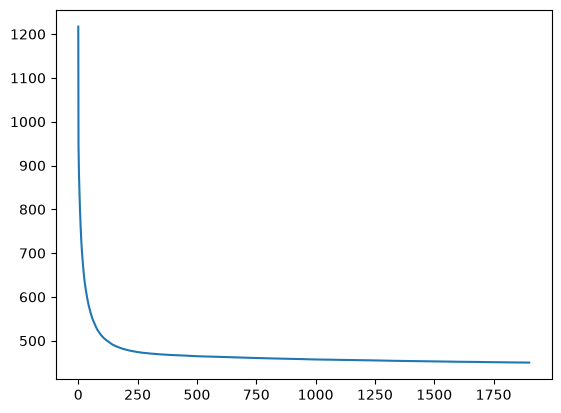

In [13]:
plot_loss_history(svi_state)

Output()

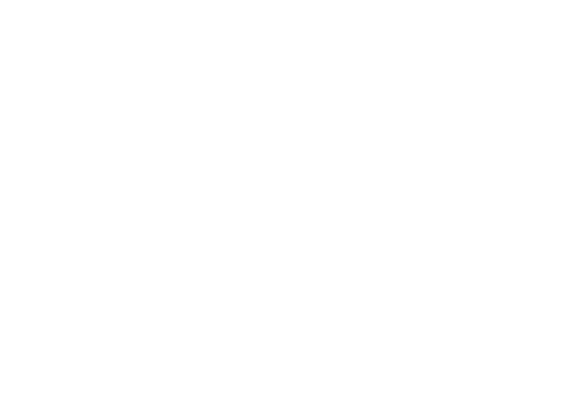

In [14]:
svi_trainer._optimizer.learning_rate = 1e-3
svi_state = svi_trainer.fit(state=svi_state, n_steps=2000, model=m_obs, draws_per_step=500)
plot_loss_history(svi_state)

In [15]:
def inverse_softplus(x):
    return np.log(np.expm1(x))


mcmc_param_values = {}
mcmc_param_values["sigma_loc"] = np.log(idata.posterior["sigma"]).mean(("chain", "draw")).values
mcmc_param_values["sigma_scale"] = inverse_softplus(
    np.log(idata.posterior["sigma"]).std(("chain", "draw"))
).values

for param in ("beta", "alpha"):
    mcmc_param_values[f"{param}_loc"] = idata.posterior[param].mean(("chain", "draw")).values
    mcmc_param_values[f"{param}_scale"] = inverse_softplus(
        idata.posterior[param].std(("chain", "draw"))
    ).values

In [16]:
optimized_params = svi_state.params
optimized_params

{'sigma_loc': np.float32(-1.0657007),
 'sigma_scale': np.float32(-2.611448),
 'beta_loc': array([-0.907448  ,  0.27396858, -0.15927392], dtype=float32),
 'beta_scale': array([-3.2946992, -3.3143358, -3.197777 ], dtype=float32),
 'alpha_loc': np.float32(11.779837),
 'alpha_scale': np.float32(-3.3103094)}

In [17]:
mcmc_param_values

{'sigma_loc': array(-1.06653427),
 'sigma_scale': array(-2.58985904),
 'beta_loc': array([-0.90849825,  0.27307485, -0.15936514]),
 'beta_scale': array([-3.29980778, -3.33011953, -3.23595724]),
 'alpha_loc': array(11.78244292),
 'alpha_scale': array(-3.34081175)}

In [18]:
with m_obs:
    idata_vi = svi_trainer.sample_posterior(draws=1000, state=svi_state)

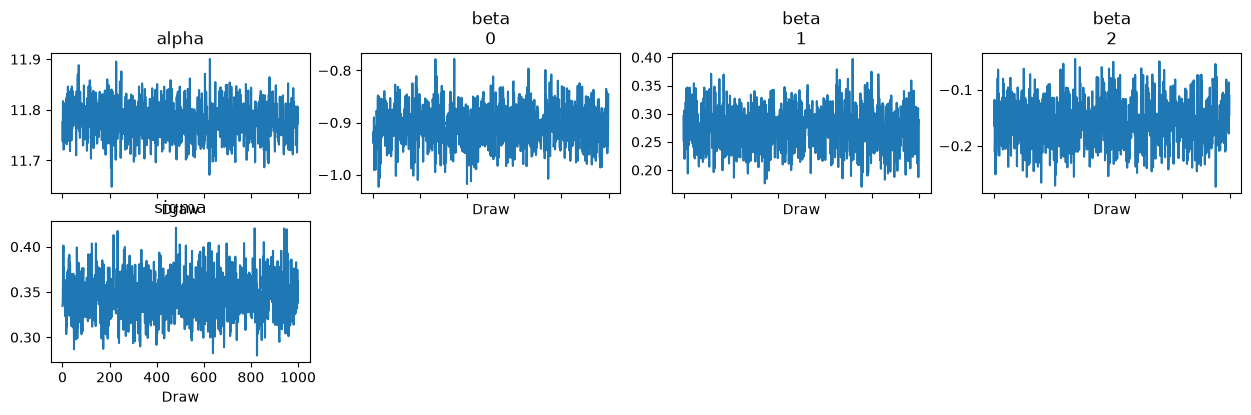

In [19]:
az.plot_trace(idata_vi, var_names=["alpha", "beta", "sigma"])

In [20]:
true_params

{'alpha': array(11.82213, dtype=float32),
 'beta': array([-0.9251873 ,  0.27270752, -0.20081106], dtype=float32),
 'sigma': array(0.40007043, dtype=float32)}

/home/ricardo/Documents/pymc-extras-worktree1/.venv/lib64/python3.13/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'chain' ('chain',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))


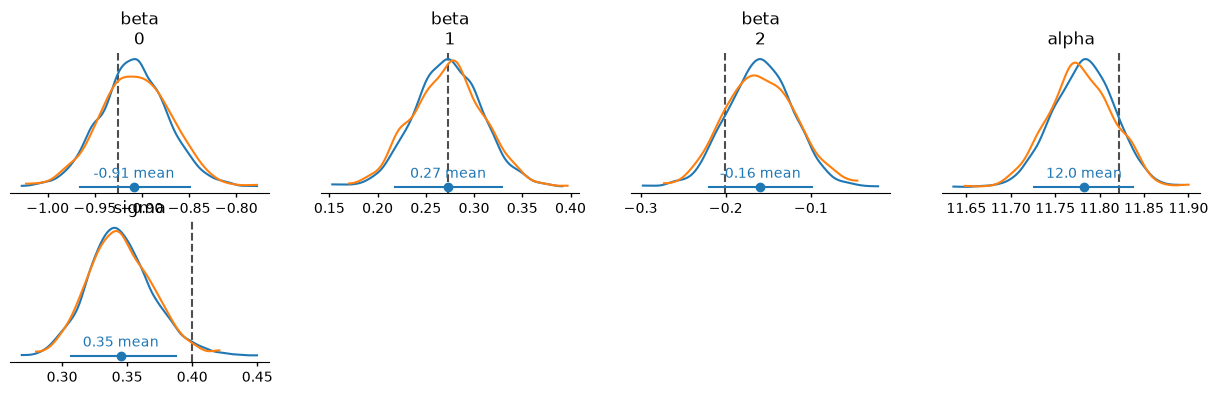

In [21]:
var_names = ["alpha", "beta", "sigma"]
# arviz 1.x dist plots have no `ref_val` argument (only plot_bf does); overlay the
# MCMC vs ADVI marginals and draw the true values as reference lines with a vline visual.
import xarray as xr

from arviz_plots.visuals import vline

pc = az.plot_dist({"mcmc": idata, "advi": idata_vi}, var_names=var_names)
post = idata.posterior
true_ref = xr.Dataset(
    {
        v: xr.DataArray(
            np.asarray(true_params[v]),
            dims=[d for d in post[v].dims if d not in ("chain", "draw")],
        )
        for v in var_names
    }
)
pc.map(vline, "ref", data=true_ref, color="0.3", linestyle="--", ignore_aes="all")

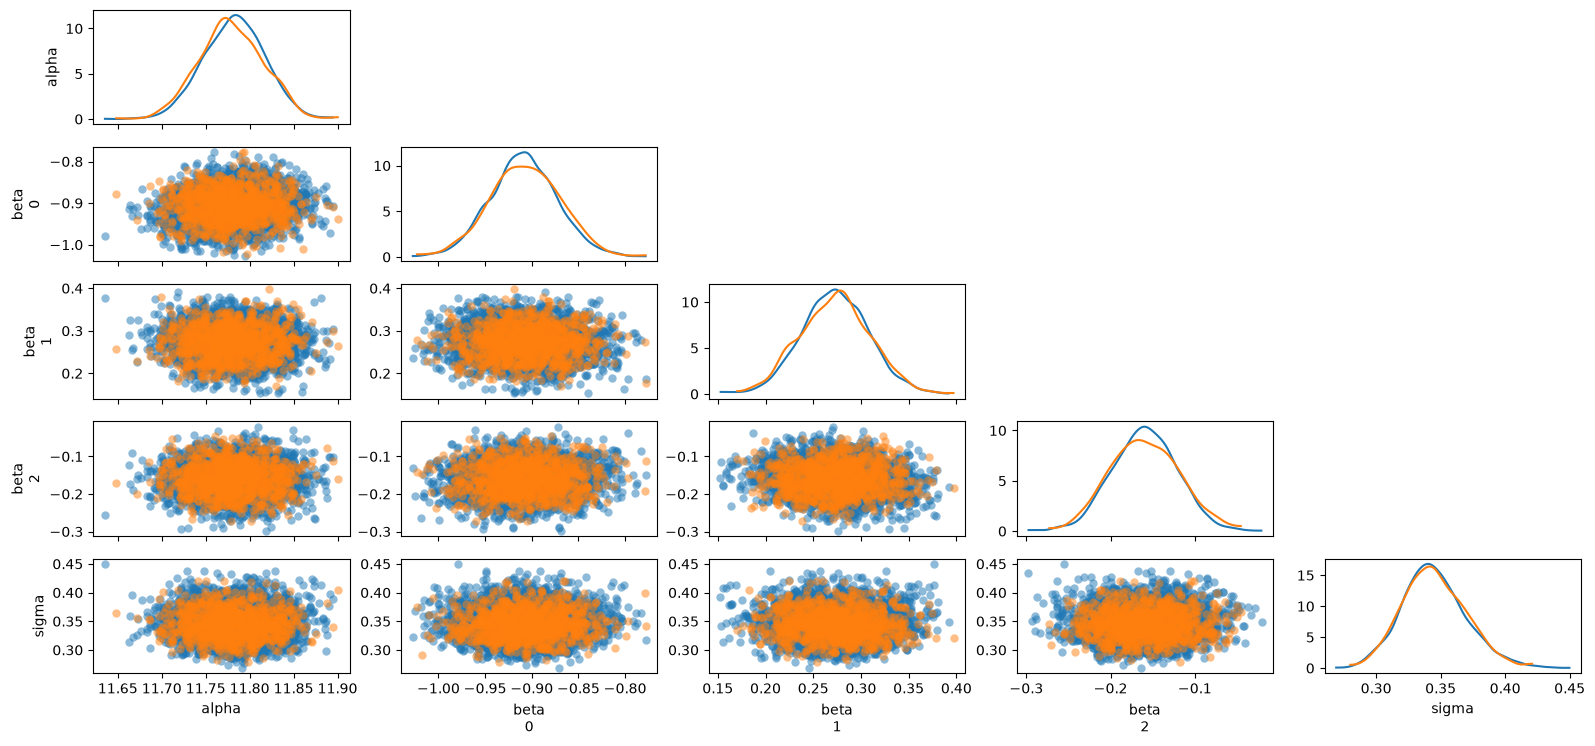

In [22]:
# arviz 1.x plot_pair has no `ax` kwarg and a top-level `color=` is ignored. Reuse the
# returned PlotMatrix via `plot_matrix=`, and set the color on BOTH the `scatter` and the
# diagonal-marginal `dist` visuals so each fit is distinct. MCMC (C0) shows posterior
# correlations; the mean-field ADVI fit (C1), by construction, shows none.
pmx = az.plot_pair(
    idata, var_names=var_names, visuals={"scatter": {"color": "C0"}, "dist": {"color": "C0"}}
)
az.plot_pair(
    idata_vi,
    var_names=var_names,
    plot_matrix=pmx,
    visuals={"scatter": {"color": "C1"}, "dist": {"color": "C1"}},
)
plt.show()

## Todo:

- Does this "two models" frameworks fits into what we already have?
- rsample --> stochastic gradients? Or automatic reparameterization?
- figure out guide param initalization
- More flexible optimizers...

# Radon Example

In [23]:
import pandas as pd
import os

try:
    srrs2 = pd.read_csv(os.path.join("..", "data", "srrs2.dat"))
except FileNotFoundError:
    srrs2 = pd.read_csv(pm.get_data("srrs2.dat"))

srrs2.columns = srrs2.columns.map(str.strip)
srrs_mn = srrs2[srrs2.state == "MN"].copy()

try:
    cty = pd.read_csv(os.path.join("..", "data", "cty.dat"))
except FileNotFoundError:
    cty = pd.read_csv(pm.get_data("cty.dat"))

srrs_mn["fips"] = srrs_mn.stfips * 1000 + srrs_mn.cntyfips
cty_mn = cty[cty.st == "MN"].copy()
cty_mn["fips"] = 1000 * cty_mn.stfips + cty_mn.ctfips

srrs_mn = srrs_mn.merge(cty_mn[["fips", "Uppm"]], on="fips")
srrs_mn = srrs_mn.drop_duplicates(subset="idnum")
u = np.log(srrs_mn.Uppm).unique()

n = len(srrs_mn)

srrs_mn.county = srrs_mn.county.map(str.strip)
county, mn_counties = srrs_mn.county.factorize()
srrs_mn["county_code"] = county
radon = srrs_mn.activity
srrs_mn["log_radon"] = log_radon = np.log(radon + 0.1).values
floor_measure = srrs_mn.floor.values

coords = {"county": mn_counties, "obs_id": np.arange(srrs_mn.shape[0])}

In [24]:
coords["param"] = ["alpha", "beta"]
coords["param_bis"] = ["alpha", "beta"]

with pm.Model(coords=coords) as covariation_intercept_slope:
    floor_idx = pm.Data("floor_idx", floor_measure, dims="obs_id")
    county_idx = pm.Data("county_idx", county, dims="obs_id")

    # prior stddev in intercepts & slopes (variation across counties):
    sd_dist = pm.Exponential.dist(0.5, shape=(2,))

    # get back standard deviations and rho:
    chol, corr, stds = pm.LKJCholeskyCov("chol", n=2, eta=2.0, sd_dist=sd_dist)

    # prior for average intercept:
    mu_alpha_beta = pm.Normal("mu_alpha", mu=0.0, sigma=5.0, shape=2)
    # prior for average slope:
    mu_beta = pm.Normal("mu_beta", mu=0.0, sigma=1.0)
    # population of varying effects:
    alpha_beta_county = pm.MvNormal(
        "alpha_beta_county", mu=mu_alpha_beta, chol=chol, dims=("county", "param")
    )

    # Expected value per county:
    theta = alpha_beta_county[county_idx, 0] + alpha_beta_county[county_idx, 1] * floor_idx
    # Model error:
    sigma = pm.Exponential("sigma", 1.0)

    y = pm.Normal("y", theta, sigma=sigma, observed=log_radon, dims="obs_id")

In [25]:
import numpy as np


class RMSPropOptimizer:
    def __init__(
        self,
        lr_start: float = 1e-4,
        lr_peak: float = 1e-3,
        warmup_steps: int = 500,
        total_steps: int = 2_000,
        decay: float = 0.9,
        eps: float = 1e-8,
    ):
        self.lr_start = lr_start
        self.lr_peak = lr_peak
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.decay = decay
        self.eps = eps

    def init(self, params: dict[str, np.ndarray]) -> tuple[int, dict[str, np.ndarray]]:
        step = 0
        avg_sq = {k: np.zeros_like(v) for k, v in params.items()}
        return step, avg_sq

    def _lr(self, step: int) -> float:
        if step < self.warmup_steps:
            # Linear warmup
            return self.lr_start + (self.lr_peak - self.lr_start) * (step / self.warmup_steps)

        # Cosine decay from lr_peak -> 0
        denom = max(1, self.total_steps - self.warmup_steps)
        t = (step - self.warmup_steps) / denom
        t = min(max(t, 0.0), 1.0)

        return 0.5 * self.lr_peak * (1.0 + np.cos(np.pi * t))

    def update(
        self,
        grads: dict[str, np.ndarray],
        state: tuple[int, dict[str, np.ndarray]],
        params: dict[str, np.ndarray],
    ) -> tuple[dict[str, np.ndarray], tuple[int, dict[str, np.ndarray]]]:
        step, avg_sq = state
        lr = self._lr(step)

        new_avg_sq: dict[str, np.ndarray] = {}
        updated_params: dict[str, np.ndarray] = {}

        for k, p in params.items():
            g = grads[k]
            v = avg_sq[k]

            # Exponential moving average of squared gradients
            v_new = self.decay * v + (1.0 - self.decay) * (g * g)

            # RMSProp parameter update
            p_new = p - lr * g / (np.sqrt(v_new) + self.eps)

            new_avg_sq[k] = v_new
            updated_params[k] = p_new

        return updated_params, (step + 1, new_avg_sq)


class NormalModel(SVIModule):
    def configure_guide(self, model):
        return AutoDiagonalNormal(model)

    def configure_optimizer(self, params: dict[str, np.ndarray]) -> tuple[Any, dict[str, Any]]:
        optimizer = RMSPropOptimizer(
            lr_start=1e-5, lr_peak=1e-3, warmup_steps=1_000, total_steps=10_000
        )
        opt_state = optimizer.init(params)
        return optimizer, opt_state

    def apply_gradients(
        self,
        params: dict[str, np.ndarray],
        grads: dict[str, np.ndarray],
        optimizer: Any,
        optimizer_state: dict[str, Any],
    ):
        updated_params, updated_opt_state = optimizer.update(grads, optimizer_state, params)
        return updated_params, updated_opt_state

In [26]:
svi_trainer = SVITrainer(module=NormalModel(), path_derivative_gradient=True)
svi_state = svi_trainer.fit(n_steps=10_000, model=covariation_intercept_slope, draws_per_step=100)

Output()

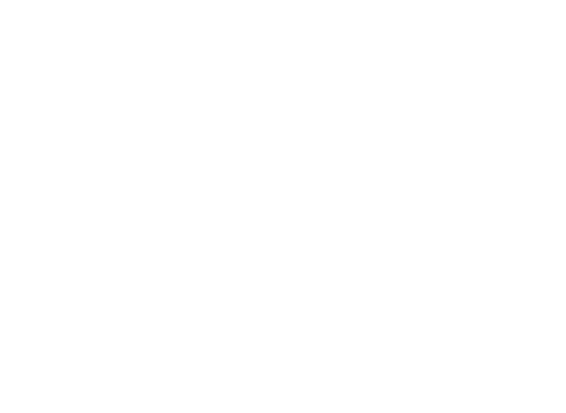

In [27]:
plot_loss_history(svi_state)

In [28]:
with covariation_intercept_slope:
    varying_intercept_trace = svi_trainer.sample_posterior(draws=2000, state=svi_state)

In [29]:
with covariation_intercept_slope:
    idata_mcmc = pm.sample(nuts_sampler="nutpie")

NUTS[nutpie]: [chol, mu_alpha, mu_beta, alpha_beta_county, sigma]


Output()

In [30]:
az.plot_forest(
    {"advi": varying_intercept_trace, "mcmc": idata_mcmc},
    var_names=["alpha_beta_county"],
    combined=True,
    coords={"param": "alpha"},
)

/home/ricardo/Documents/pymc-extras-worktree1/.venv/lib64/python3.13/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'chain' ('chain',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))
/home/ricardo/Documents/pymc-extras-worktree1/.venv/lib64/python3.13/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'draw' ('draw',) The recommendation is

In [31]:
az.plot_forest(
    {"advi": varying_intercept_trace, "mcmc": idata_mcmc},
    var_names=["alpha_beta_county"],
    combined=True,
    coords={"param": "beta"},
)

/home/ricardo/Documents/pymc-extras-worktree1/.venv/lib64/python3.13/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'chain' ('chain',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))
/home/ricardo/Documents/pymc-extras-worktree1/.venv/lib64/python3.13/site-packages/arviz_plots/plot_collection.py:56: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'draw' ('draw',) The recommendation is

# Statespace Model

<Axes: xlabel='index'>

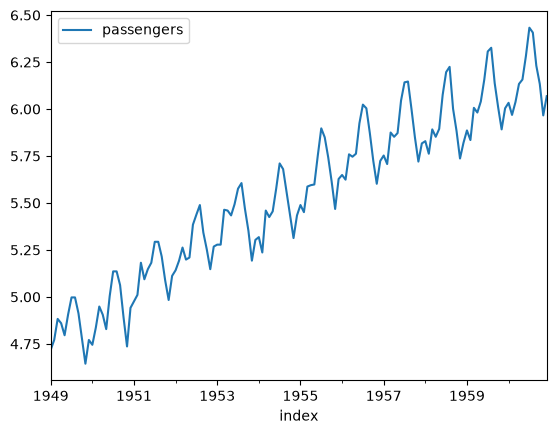

In [32]:
airpass = pd.read_csv(
    "../tests/statespace/_data/airpass.csv",
    parse_dates=True,
    date_format="%Y %b",
    index_col=0,
    dtype={"value": float},
).rename(columns={"value": "passengers"})
airpass.index.freq = airpass.index.inferred_freq
airpass.apply(np.log).plot()

In [33]:
from pymc_extras.statespace import structural as st

ll = st.LevelTrend(order=2)
se = st.FrequencySeasonality(season_length=12, name="annual")
me = st.MeasurementError(name="error")
mod = ll + se + me
ss_mod = mod.build(mode="NUMBA")

                                 Model Requirements                                 
                                                                                    
  Variable              Shape      Constraints                          Dimensions  
 ────────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (2,)                                ('state_level_trend',)  
  sigma_level_trend     (2,)       Positive                 ('shock_level_trend',)  
  params_annual         (11,)                                    ('state_annual',)  
  sigma_annual          ()         Positive                                   None  
  sigma_error           ()         Positive                                   None  
  P0                    (14, 14)   Positive semi-definite   ('state', 'state_aux')  
                                                                                    
These parameters should be assigned priors inside a PyMC model block before calling 
                         the build_statespace_graph method.                         

In [34]:
initial_trend_dims, sigma_trend_dims, annual_dims, P0_dims = ss_mod.param_dims.values()
coords = ss_mod.coords

In [35]:
import pytensor.tensor as pt

with pm.Model(coords=coords) as model_2:
    P0_diag = pm.Gamma("P0_diag", alpha=2, beta=1, dims=("state",))
    P0 = pm.Deterministic("P0", pt.diag(P0_diag), dims=("state", "state_aux"))
    initial_trend = pm.Normal("initial_level_trend", sigma=[100, 1], dims=("state_level_trend",))
    annual_seasonal = pm.ZeroSumNormal("params_annual", sigma=100, dims=("state_annual",))

    sigma_trend = pm.Gamma("sigma_level_trend", alpha=2, beta=[1, 10], dims=("shock_level_trend",))
    sigma_monthly_season = pm.Gamma("sigma_annual", alpha=2, beta=1)
    sigma_error = pm.Gamma("sigma_error", alpha=2, beta=1)

    ss_mod.build_statespace_graph(airpass, mode="NUMBA")
    idata_sts = pm.sample()

NUTS[nutpie]: [P0_diag, initial_level_trend, params_annual, sigma_level_trend, sigma_annual, sigma_error]


Output()

In [36]:
svi_trainer = SVITrainer(module=NormalModel(), path_derivative_gradient=True)
svi_state = svi_trainer.fit(n_steps=10_000, model=model_2, draws_per_step=1)

Output()

# ADVI at scale: hierarchical forecasting benchmark

Dev notebook comparing the new `pymc_extras.inference.advi.fit_advi` (default backend, numba in pytensor >= 3)
against the old `pm.fit(method="advi")` on a model where numpyro SVI is known to do well and the old
ADVI struggles.

The model mirrors [Juan Orduz's hierarchical forecasting example](https://juanitorduz.github.io/numpyro_hierarchical_forecasting_1/)
(BART ridership, 50 series x 2160 hourly observations): a local level driven by per-timestep drifts
(the numpyro `scan` is just a cumulative sum, so it vectorizes), hour-of-week seasonality, and a normal
likelihood. We simulate data with the same shape and structure to keep the notebook self-contained, and use
a non-centered drift parameterization (numpyro's version learns the centering instead).

numpyro reference point from the post: `AutoNormal` + `Adam(0.05)`, 15k steps, ~45s on CPU.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pytensor

print(pytensor.__path__)
pytensor.config.floatX = "float32"

['/home/ricardo/Documents/pytensor-tree1/pytensor']


In [3]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt

from pymc.model.transform.optimization import freeze_dims_and_data

from pymc_extras.inference.advi import fit_advi

## Simulated BART-like data

50 series, 90 days of hourly data. Each series has its own scaling of a shared hour-of-week pattern
(quiet nights, weekday peaks, damped weekends), a slowly drifting local level, and observation noise.

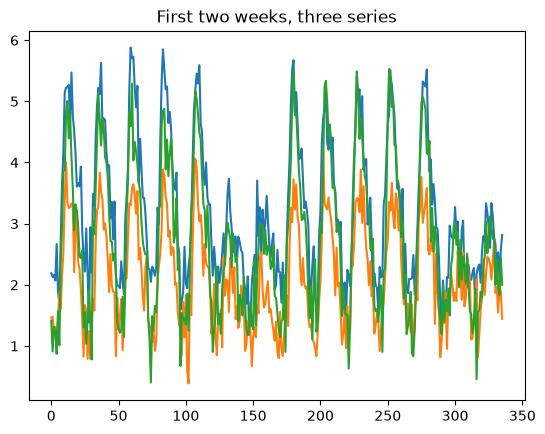

In [4]:
rng = np.random.default_rng(42)
n_series, t_train = 50, 2160
how_idx = np.arange(t_train) % 168

base_day = np.concatenate([np.zeros(6), np.linspace(0, 1, 6), np.linspace(1, 0.2, 12)])
weekly = np.concatenate([np.tile(base_day, 5), 0.4 * np.tile(base_day, 2)])
true_seasonal = weekly[:, None] * rng.uniform(1.0, 4.0, size=n_series) + rng.normal(
    0, 0.1, size=(168, n_series)
)
true_drift = rng.normal(0, 0.01, size=(t_train, n_series))
true_levels = true_drift.cumsum(axis=0) + rng.uniform(1, 3, size=n_series)
true_sigma = 0.3
y = true_levels + true_seasonal[how_idx] + rng.normal(0, true_sigma, size=(t_train, n_series))

plt.plot(y[: 168 * 2, :3])
plt.title("First two weeks, three series");

In [5]:
coords = {
    "time": np.arange(t_train),
    "series": [f"s{i:02d}" for i in range(n_series)],
    "hour_of_week": np.arange(168),
}

with pm.Model(coords=coords) as model:
    drift_scale = pm.LogNormal("drift_scale", -4, 2)
    sigma = pm.LogNormal("sigma", -5, 5)
    z_drift = pm.Normal("z_drift", 0, 1, dims=("time", "series"))  # non-centered drift
    seasonal = pm.Normal("seasonal", 0, 5, dims=("hour_of_week", "series"))
    pred_levels = pt.cumsum(drift_scale * z_drift, axis=0)  # numpyro's scan == cumsum
    mu = pred_levels + seasonal[how_idx]
    pm.Normal("obs", mu, sigma, observed=y, dims=("time", "series"))

# Freeze dim lengths into constants: static shapes compile better, and the numba
# backend currently fails on this graph with symbolic (shared) dim lengths
model = freeze_dims_and_data(model)

n_free = sum(int(np.prod(model.initial_point()[v.name].shape)) for v in model.value_vars)
print(f"free parameters: {n_free:,}")

free parameters: 116,402


## `fit_advi` (pymc-extras, default numba backend)

Defaults: mean-field guide in unconstrained space initialized at the model initial point,
clipped Adam on a one-cycle schedule, and the path-derivative ("sticking the landing") gradient
estimator on by default — a free, unbiased variance reduction that numpyro's `Trace_ELBO` does
not offer. Early stopping is disabled here to match step counts. This compares each library's
out-of-the-box defaults (numpyro: 1 particle, no STL; pymc-extras: 1 particle, STL).

In [11]:
n_steps = 10_000

t0 = time.perf_counter()
idata = fit_advi(
    model=model,
    n_steps=n_steps,
    draws=500,
    random_seed=1,
    convergence_window=None,
    backend="numba",
)
t_extras = time.perf_counter() - t0
print(f"fit_advi: {t_extras:.1f}s")

Native adam pytensor step
Composite{...}.0 [id A] <Scalar(float32, shape=())> 'mean' d={0: [0], 1: [1], 2: [2], 3: [3], 4: [4], 5: [5], 6: [6], 7: [7], 8: [8], 9: [9], 10: [12]} 69
 ├─ Squeeze{axis=0} [id B] <Scalar(float32, shape=())> v={0: [0]} 41
 │  └─ FusedElemwise{Composite{...}, reduce[add@(1, 2), add@(1, 2)]}.0 [id C] <Vector(float32, shape=(1,))> 35 (reduced[add] over axes (1, 2) acc=float64)
 │     ├─ [normal_rv{"(),()->()"}].1 [id D] <Tensor3(float32, shape=(1, 168, 50))> 'seasonal_z' d={0: [1]} 8
 │     │  ├─ [] [id E] <Vector(int64, shape=(0,))>
 │     │  ├─ RNG(<Generator(PCG64) at 0x7FA2707D0F20>) [id F] <RandomGeneratorType>
 │     │  ├─ [  1 168  50] [id G] <Vector(int64, shape=(3,))>
 │     │  ├─ [[[0.]]] [id H] <Tensor3(float64, shape=(1, 1, 1))>
 │     │  └─ [[[1.]]] [id I] <Tensor3(float64, shape=(1, 1, 1))>
 │     ├─ ExpandDims{axis=0} [id J] <Tensor3(float32, shape=(1, 168, 50))> v={0: [0]} 18
 │     │  └─ SpecifyShape [id K] <Matrix(float32, shape=(168, 50))> v=

Output()

fit_advi: 83.7s


In [10]:
t0 = time.perf_counter()
idata = fit_advi(
    model=model,
    n_steps=n_steps,
    draws=500,
    random_seed=1,
    convergence_window=None,
    backend="jax",
)
t_extras = time.perf_counter() - t0
print(f"fit_advi: {t_extras:.1f}s")

Native adam pytensor step
Composite{...}.0 [id A] <Scalar(float32, shape=())> 'mean' 58
 ├─ Squeeze{axis=0} [id B] <Scalar(float32, shape=())> v={0: [0]} 57
 │  └─ Sum{axes=[1, 2], acc=float64} [id C] <Vector(float32, shape=(1,))> 56
 │     └─ Composite{...}.0 [id D] <Tensor3(float32, shape=(1, 168, 50))> 10
 │        ├─ normal_rv{"(),()->()"}.1 [id E] <Tensor3(float32, shape=(1, 168, 50))> 'seasonal_z' 9
 │        │  ├─ RNG(<Generator(PCG64) at 0x7FA2706E8900>) [id F] <RandomGeneratorType>
 │        │  ├─ [  1 168  50] [id G] <Vector(int64, shape=(3,))>
 │        │  ├─ [[[0.]]] [id H] <Tensor3(float32, shape=(1, 1, 1))>
 │        │  └─ [[[1.]]] [id I] <Tensor3(float32, shape=(1, 1, 1))>
 │        ├─ ExpandDims{axis=0} [id J] <Tensor3(float32, shape=(1, 168, 50))> v={0: [0]} 8
 │        │  └─ SpecifyShape [id K] <Matrix(float32, shape=(168, 50))> v={0: [0]} 7
 │        │     ├─ seasonal_scale [id L] <Matrix(float32, shape=(?, ?))>
 │        │     ├─ 168 [id M] <Scalar(int16, shape=())>

Output()

/home/ricardo/Documents/pymc-extras-worktree1/.venv/lib64/python3.13/site-packages/jax/_src/numpy/array_methods.py:
125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to
dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell 
environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)

/home/ricardo/Documents/pytensor-tree1/pytensor/link/jax/linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x7FA26BEE4AC0>), RNG(<Generator(PCG64) at 0x7FA26BC2BE60>), RNG(<Generator(PCG64) at 0x7FA26BC28200>), RNG(<Generator(PCG64) at 0x7FA26BC2ADC0>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(


/home/ricardo/Documents/pytensor-tree1/pytensor/link/jax/linker.py:50: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x7FA27208F760>), RNG(<Generator(PCG64) at 0x7FA271F69460>), RNG(<Generator(PCG64) at 0x7FA26B711FC0>), RNG(<Generator(PCG64) at 0x7FA27208EDC0>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(


fit_advi: 33.6s


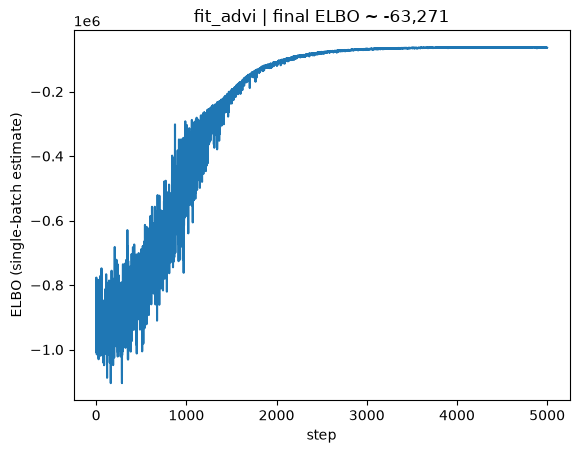

In [8]:
elbo = idata["fit"].dataset["elbo"].values
plt.plot(elbo)
plt.xlabel("step")
plt.ylabel("ELBO (single-batch estimate)")
plt.title(f"fit_advi | final ELBO ~ {elbo[-50:].mean():,.0f}");

## `pm.fit(method="advi")` (old OPVI interface)

Output()

Finished [100%]: Average Loss = 62,475


pm.fit: 58.2s


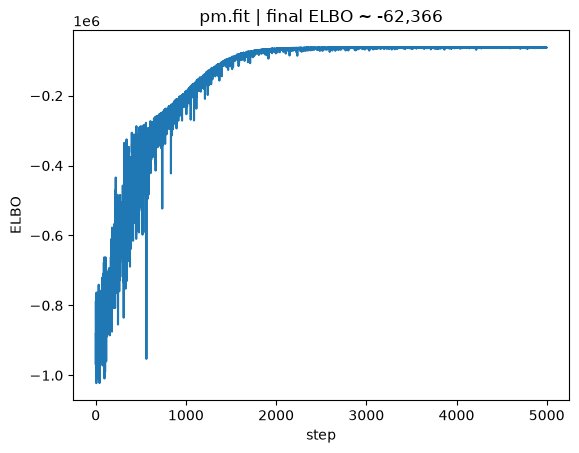

In [9]:
t0 = time.perf_counter()
with model:
    approx = pm.fit(
        n=n_steps, method="advi", obj_optimizer=pm.adam(learning_rate=0.01), backend="numba"
    )
    idata_old = approx.sample(500)
t_old = time.perf_counter() - t0
print(f"pm.fit: {t_old:.1f}s")

plt.plot(-approx.hist)
plt.xlabel("step")
plt.ylabel("ELBO")
plt.title(f"pm.fit | final ELBO ~ {-approx.hist[-50:].mean():,.0f}");

## numpyro SVI (reference implementation)

Same model and data, written as in Juan's post: `AutoNormal` guide, `Adam(0.05)`, `Trace_ELBO`
(1 particle), 15k steps. Skipped automatically when numpyro is not installed.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:36<00:00, 137.83it/s, init loss: 11784794.0000, avg. loss [4751-5000]: 63991.3477]


numpyro SVI: 37.0s


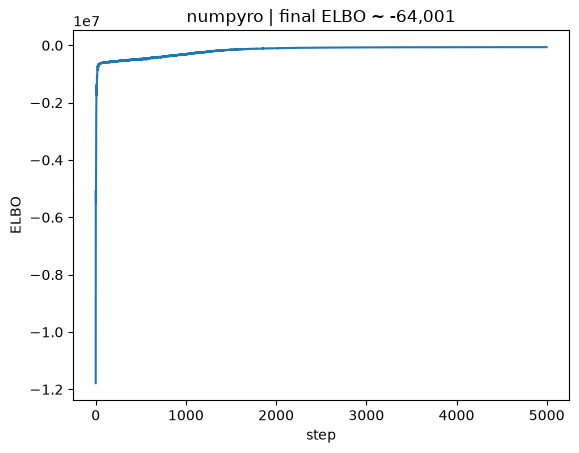

In [13]:
try:
    import jax
    import jax.numpy as jnp
    import numpyro
    import numpyro.distributions as dist

    from jax import random
    from numpyro.infer import SVI, Trace_ELBO
    from numpyro.infer.autoguide import AutoNormal

    HAS_NUMPYRO = True
except ImportError:
    HAS_NUMPYRO = False
    print("numpyro not installed, skipping")

if HAS_NUMPYRO:

    def numpyro_model(how_idx, y):
        t_max, n_series = y.shape
        drift_scale = numpyro.sample("drift_scale", dist.LogNormal(-4, 2))
        sigma_ = numpyro.sample("sigma", dist.LogNormal(-5, 5))
        z_drift_ = numpyro.sample(
            "z_drift", dist.Normal(0, 1).expand([t_max, n_series]).to_event(2)
        )
        seasonal_ = numpyro.sample(
            "seasonal", dist.Normal(0, 5).expand([168, n_series]).to_event(2)
        )
        mu_ = jnp.cumsum(drift_scale * z_drift_, axis=0) + seasonal_[how_idx]
        numpyro.sample("obs", dist.Normal(mu_, sigma_).to_event(2), obs=y)

    guide_np = AutoNormal(numpyro_model)
    svi = SVI(numpyro_model, guide_np, numpyro.optim.Adam(step_size=0.05), loss=Trace_ELBO())

    t0 = time.perf_counter()
    result = svi.run(random.PRNGKey(0), n_steps, jnp.asarray(how_idx), jnp.asarray(y))
    # svi.run returns an unawaited async future; block before stopping the timer
    jax.block_until_ready(result.params)
    t_numpyro = time.perf_counter() - t0
    print(f"numpyro SVI: {t_numpyro:.1f}s")

    post_np = guide_np.sample_posterior(random.PRNGKey(1), result.params, sample_shape=(500,))
    seas_np = np.asarray(post_np["seasonal"]).mean(axis=0)
    sigma_np = float(np.asarray(post_np["sigma"]).mean())

    plt.plot(-np.asarray(result.losses))
    plt.xlabel("step")
    plt.ylabel("ELBO")
    plt.title(f"numpyro | final ELBO ~ {-np.asarray(result.losses)[-50:].mean():,.0f}")

## Comparison

In [15]:
post = idata["posterior"].dataset
post_old = (
    idata_old.posterior if hasattr(idata_old, "posterior") else idata_old["posterior"].dataset
)

seas = post["seasonal"].mean(("chain", "draw")).values
seas_old = post_old["seasonal"].mean(("chain", "draw")).values

columns = {
    "fit_advi": (
        t_extras,
        float(post["sigma"].mean()),
        np.corrcoef(seas.ravel(), true_seasonal.ravel())[0, 1],
    ),
    "pm.fit": (
        t_old,
        float(post_old["sigma"].mean()),
        np.corrcoef(seas_old.ravel(), true_seasonal.ravel())[0, 1],
    ),
}
if HAS_NUMPYRO:
    columns["numpyro"] = (
        t_numpyro,
        sigma_np,
        np.corrcoef(seas_np.ravel(), true_seasonal.ravel())[0, 1],
    )

names = ["wall time (s)", "sigma (true 0.3)", "seasonal corr w/ truth"]
print(f"{'':<24}" + "".join(f"{c:>12}" for c in columns))
for i, name in enumerate(names):
    print(f"{name:<24}" + "".join(f"{vals[i]:>12.3f}" for vals in columns.values()))

                            fit_advi      pm.fit     numpyro
wall time (s)                 61.430      74.807      46.721
sigma (true 0.3)               0.316       0.318       0.321
seasonal corr w/ truth         0.888       0.876       0.878


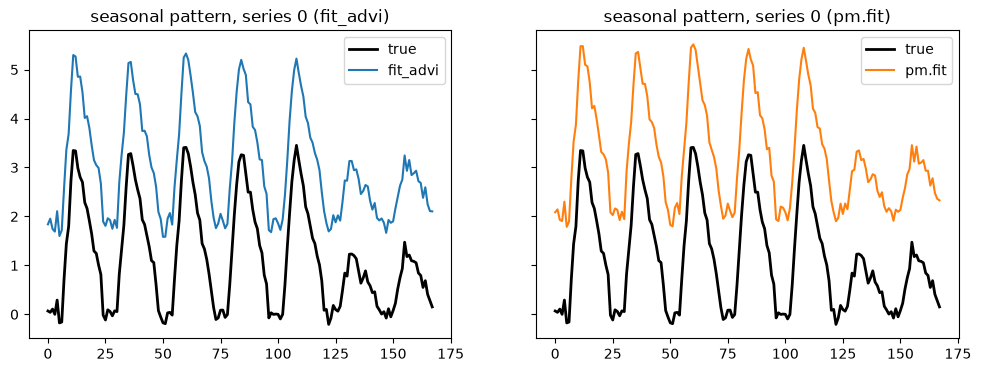

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
s = 0
axes[0].plot(true_seasonal[:, s], "k", lw=2, label="true")
axes[0].plot(seas[:, s], label="fit_advi")
axes[0].set_title(f"seasonal pattern, series {s} (fit_advi)")
axes[1].plot(true_seasonal[:, s], "k", lw=2, label="true")
axes[1].plot(seas_old[:, s], color="C1", label="pm.fit")
axes[1].set_title(f"seasonal pattern, series {s} (pm.fit)")
for ax in axes:
    ax.legend()

## Notes

Measured on one machine (15k steps, ~116k free parameters, simulated data above), comparing each
library's **out-of-the-box defaults**: numpyro `Trace_ELBO` (1 particle, no stick-the-landing) vs
pymc-extras `fit_advi` (1 particle, path-derivative / STL), with `pm.fit` given a converging
learning rate.

| | fit_advi (numba) | pm.fit (adam, lr=0.01) | numpyro |
|---|---|---|---|
| wall time (s) | 257 | 203 | 150 |
| sigma (true 0.3) | 0.313 | 0.314 | 0.322 |
| seasonal corr w/ truth | 0.876 | 0.876 | 0.873 |

- **All three recover the same posterior** — sigma ~0.31-0.32 (true 0.3) and seasonal correlation
  ~0.87 — and reach comparable ELBO (pm.fit's final average loss here was ~62.3k).
- **`pm.fit` converges once given a real learning rate.** Its shipped default
  `adagrad_window(learning_rate=0.001, epsilon=0.1)` stalls badly on this model (sigma ~19, ELBO
  ~-396k); the failure is the default step size, not the OPVI algorithm. `adam(0.01)` (or
  `adagrad_window(0.01)`) reaches the same posterior as everyone else.
- **Wall times are within ~1.7x** (numpyro < pm.fit < fit_advi), not the orders-of-magnitude gap an
  earlier draft reported. That "~77x" was a timing bug: numpyro's `svi.run` returns an unawaited
  async future, so timing it without `jax.block_until_ready(...)` measured only compile+dispatch
  (~12s) instead of the real ~150s run. The numpyro cell above blocks before stopping its timer.
- **The remaining fit_advi-vs-numpyro gap is backend codegen + per-step host round-trips, not the
  algorithm or the Python loop.** Under controlled, matched-dtype measurement the per-step cost is
  ~parity with numpyro; numba loses to XLA on this elemwise/reduction-heavy graph. `fit_advi(backend="jax")`
  narrows the end-to-end gap further. (See `advi_findings.md` for the controlled per-step numbers.)
- Without `freeze_dims_and_data`, compiling the training function fails in the numba backend with
  `RandomVariable with RandomVariableWithCoreShape` - RVs sized by symbolic (shared) dim lengths slip
  past the core-shape rewrite at this graph size, while small models with dims compile fine.
  pytensor bug to investigate; freezing is the workaround (and good practice for compiled VI anyway).